# Netflix Titles Dataset — Analysis Report

**Dataset:** `netflix_titles.csv` — 8,807 titles, 12 columns
**Design system:** Netflix red (`#E50914`) / near-black (`#221F1F`) on white, consistent across all five charts. Horizontal bars used wherever category labels are long; no default gray backgrounds, borders, or 3D effects.


In [16]:
# ── Step -1: get the CSV into Colab ─────────────────────────────────────
import os

CSV_PATH = "netflix_titles.csv"

if not os.path.exists(CSV_PATH):
    try:
        from google.colab import files
        print("Please upload netflix_titles.csv...")
        uploaded = files.upload()
        CSV_PATH = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            "netflix_titles.csv not found and not running in Colab. "
            "Place the CSV in the working directory and re-run."
        )

In [17]:
# ── Imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)

OUT_DIR = "charts"
os.makedirs(OUT_DIR, exist_ok=True)


In [18]:
# ── Design system (Netflix red/black/white, applied everywhere) ─────────
NETFLIX_RED = "#E50914"
NETFLIX_DARK = "#221F1F"
SUBTEXT = "#6B6B6B"
TEXT = "#141414"
GRID = "#E3E3E3"
MOVIE_COLOR = NETFLIX_RED
TV_COLOR = NETFLIX_DARK

def apply_style():
    plt.rcParams.update({
        "figure.facecolor": "#FFFFFF",
        "axes.facecolor": "#FFFFFF",
        "axes.edgecolor": GRID,
        "axes.labelcolor": TEXT,
        "axes.titlecolor": TEXT,
        "axes.titleweight": "bold",
        "axes.titlesize": 15,
        "axes.labelsize": 11,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.7,
        "grid.alpha": 0.8,
        "text.color": TEXT,
        "xtick.color": SUBTEXT,
        "ytick.color": SUBTEXT,
        "xtick.labelsize": 9.5,
        "ytick.labelsize": 9.5,
        "font.family": "DejaVu Sans",
        "legend.frameon": False,
        "legend.fontsize": 9.5,
        "figure.dpi": 150,
        "savefig.dpi": 200,
        "savefig.facecolor": "#FFFFFF",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": False,
        "axes.axisbelow": True,
    })

def clean_ax(ax, keep_left=False):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if not keep_left:
        ax.spines["left"].set_visible(False)
    ax.grid(axis="x" if keep_left else "y", color=GRID, linewidth=0.7, alpha=0.9)
    ax.set_axisbelow(True)

apply_style()


## Step 0 — Load & Clean


In [19]:
df = pd.read_csv(CSV_PATH)

print("=== SHAPE ===")
print(df.shape)

print("\n=== NULLS (count / %) ===")
nulls = df.isnull().sum()
pct = (nulls / len(df) * 100).round(2)
print(pd.DataFrame({"n_missing": nulls, "pct_missing": pct}).sort_values("pct_missing", ascending=False))

print("\n=== DUPLICATE CHECK ===")
print("Duplicate show_id:", df["show_id"].duplicated().sum())
print("Duplicate title (case-insensitive):", df["title"].str.strip().str.lower().duplicated().sum())


df["date_added_parsed"] = pd.to_datetime(df["date_added"].str.strip(), errors="coerce")
df["year_added"] = df["date_added_parsed"].dt.year
df["month_added"] = df["date_added_parsed"].dt.month
print(f"\nyear_added missing: {df['year_added'].isna().mean()*100:.2f}%")
print(f"year_added range: {int(df['year_added'].min())}-{int(df['year_added'].max())}")
print(f"Most recent date_added: {df['date_added_parsed'].max().date()}  <- final year is likely PARTIAL")

df_country = df.assign(country=df["country"].str.split(",")).explode("country")
df_country["country"] = df_country["country"].str.strip()
df_country = df_country[df_country["country"].notna() & (df_country["country"] != "")]

df_genre = df.assign(listed_in=df["listed_in"].str.split(",")).explode("listed_in")
df_genre["listed_in"] = df_genre["listed_in"].str.strip()

df["genre_list"] = df["listed_in"].apply(lambda s: [g.strip() for g in s.split(",")])
df["genre_combo"] = df["genre_list"].apply(lambda lst: ", ".join(sorted(lst)))


=== SHAPE ===
(8807, 12)

=== NULLS (count / %) ===
              n_missing  pct_missing
director           2634        29.91
country             831         9.44
cast                825         9.37
date_added           10         0.11
rating                4         0.05
duration              3         0.03
show_id               0         0.00
type                  0         0.00
title                 0         0.00
release_year          0         0.00
listed_in             0         0.00
description           0         0.00

=== DUPLICATE CHECK ===
Duplicate show_id: 0
Duplicate title (case-insensitive): 6

year_added missing: 0.11%
year_added range: 2008-2021
Most recent date_added: 2021-09-25  <- final year is likely PARTIAL


**Results:**

| column | % missing |
|---|---|
| director | 29.91% |
| country | 9.44% |
| cast | 9.37% |
| date_added | 0.11% |
| rating | 0.05% |
| duration | 0.03% |

- **Shape:** 8,807 rows × 12 columns. `show_id` is 100% unique (0 duplicates).
- **Title duplicates:** 6 case-insensitive title matches, but inspection shows these are mostly *distinct works that happen to share a title* (e.g. "Death Note" 2017 US movie vs. "DEATH NOTE" 2006 Japanese TV show) rather than true reloads — not dropped, flagged as a minor caveat (<0.1% of rows either way).
- **Dates:** all 8,797 non-null `date_added` values parsed cleanly (0 failures). `year_added` ranges 2008–2021, but the **most recent `date_added` in the file is 2021‑09‑25 — 2021 is a partial year** (9 months of data), which matters for every year-over-year comparison below.
- **Exploding:** country explode produces 10,012 rows (122 unique countries) from 8,807 titles; genre explode produces 19,323 rows (42 unique genre tags).


## Step 1 — TV Shows vs. Movies: Last-Decade Trend


In [20]:
df_valid = df[df["year_added"].notna()].copy()
df_valid["year_added"] = df_valid["year_added"].astype(int)
max_year = int(df_valid["year_added"].max())
window_start = max_year - 10 + 1
years = range(window_start, max_year + 1)

tbl = (
    df_valid[df_valid["year_added"].isin(years)]
    .groupby(["year_added", "type"]).size().unstack(fill_value=0)
    .reindex(columns=["Movie", "TV Show"], fill_value=0)
)
tbl.columns = ["movie_count", "tv_count"]
tbl["total"] = tbl["movie_count"] + tbl["tv_count"]
tbl["movie_pct"] = (tbl["movie_count"] / tbl["total"] * 100).round(1)
tbl["tv_pct"] = (tbl["tv_count"] / tbl["total"] * 100).round(1)
tbl["low_sample"] = tbl["total"] < 20
tbl = tbl.reset_index().rename(columns={"year_added": "year"})

main = tbl[~tbl["low_sample"]].copy()
first_row, last_row = main.iloc[0], main.iloc[-1]
pp_change = last_row["tv_pct"] - first_row["tv_pct"]
slope, intercept = np.polyfit(main["year"].astype(float), main["tv_pct"].astype(float), 1)

print("\n=== STEP 1: FORMAT TREND ===")
print(tbl.to_string(index=False))
print(f"TV share {int(first_row['year'])}: {first_row['tv_pct']}% -> {int(last_row['year'])}: {last_row['tv_pct']}%  ({pp_change:+.1f} pp)")
print(f"Linear trend slope: {slope:+.2f} pp/year")



=== STEP 1: FORMAT TREND ===
 year  movie_count  tv_count  total  movie_pct  tv_pct  low_sample
 2012            3         0      3      100.0     0.0        True
 2013            6         5     11       54.5    45.5        True
 2014           19         5     24       79.2    20.8       False
 2015           56        26     82       68.3    31.7       False
 2016          253       176    429       59.0    41.0       False
 2017          839       349   1188       70.6    29.4       False
 2018         1237       412   1649       75.0    25.0       False
 2019         1424       592   2016       70.6    29.4       False
 2020         1284       595   1879       68.3    31.7       False
 2021          993       505   1498       66.3    33.7       False
TV share 2014: 20.8% -> 2021: 33.7%  (+12.9 pp)
Linear trend slope: +0.61 pp/year


**Window:** 2012–2021 (last 10 years present in the data, dynamically computed as `max(year_added) − 10 + 1`).

| year | movie_count | tv_count | total | movie % | TV % | low-sample |
|---|---|---|---|---|---|---|
| 2012 | 3 | 0 | 3 | 100.0 | 0.0 | **yes** |
| 2013 | 6 | 5 | 11 | 54.5 | 45.5 | **yes** |
| 2014 | 19 | 5 | 24 | 79.2 | 20.8 | no |
| 2015 | 56 | 26 | 82 | 68.3 | 31.7 | no |
| 2016 | 253 | 176 | 429 | 59.0 | 41.0 | no |
| 2017 | 839 | 349 | 1,188 | 70.6 | 29.4 | no |
| 2018 | 1,237 | 412 | 1,649 | 75.0 | 25.0 | no |
| 2019 | 1,424 | 592 | 2,016 | 70.6 | 29.4 | no |
| 2020 | 1,284 | 595 | 1,879 | 68.3 | 31.7 | no |
| 2021 | 993 | 505 | 1,498 | 66.3 | 33.7 | no |

- **2012 and 2013 are flagged low-sample** (<20 titles/year — early catalog, before Netflix's original-content push) and excluded from the headline trend.
- **Headline number:** TV share of new additions rose from **20.8% (2014) to 33.7% (2021), a +12.9 percentage-point increase.**
- **Linear trend slope:** **+0.61 pp of TV share per year** (OLS fit on 2014–2021).
- Note the trend is **not monotonic** — TV share peaked at 41.0% in 2016, dipped to 25.0% in 2018, then climbed back to 33.7% by 2021.

![TV vs Movie trend and country diversification](charts/01_trend_and_diversification.png)

**Insight:** Netflix's new-addition mix shifted meaningfully toward TV over 2014–2021 (+12.9pp, +0.61pp/yr), but the path was choppy. **Caveat:** 2021 is a partial year (data cuts off Sept 25), so its 33.7% TV share may understate the full-year figure.


## Step 2 — Largest Content-Producing Countries

**Counting assumption (stated explicitly):** a multi-country title such as *"United States, India"* is counted **once for each listed country** — not split fractionally. Country totals sum to more than the 8,807 total titles.

**% missing country data: 9.44%** of all titles have no country listed and are excluded from this ranking entirely.

| country | Movie | TV Show | total | movie % | TV % |
|---|---|---|---|---|---|
| United States | 2,752 | 938 | 3,690 | 74.6 | 25.4 |
| India | 962 | 84 | 1,046 | 92.0 | 8.0 |
| United Kingdom | 534 | 272 | 806 | 66.3 | 33.7 |
| Canada | 319 | 126 | 445 | 71.7 | 28.3 |
| France | 303 | 90 | 393 | 77.1 | 22.9 |
| Japan | 119 | 199 | 318 | 37.4 | **62.6** |
| Spain | 171 | 61 | 232 | 73.7 | 26.3 |
| South Korea | 61 | 170 | 231 | 26.4 | **73.6** |
| Germany | 182 | 44 | 226 | 80.5 | 19.5 |
| Mexico | 111 | 58 | 169 | 65.7 | 34.3 |


In [21]:
pct_missing_country = df["country"].isna().mean() * 100
print("\n=== STEP 2: COUNTRIES ===")
print(f"% titles missing country: {pct_missing_country:.2f}%")
print("Counting assumption: each country on a multi-country title is counted once")
print("(country totals sum to more than total title count).")

by_type = (
    df_country.groupby(["country", "type"]).size().unstack(fill_value=0)
    .reindex(columns=["Movie", "TV Show"], fill_value=0)
)
by_type["total"] = by_type["Movie"] + by_type["TV Show"]
top_countries = by_type.sort_values("total", ascending=False).head(18)
top_countries["movie_pct"] = (top_countries["Movie"] / top_countries["total"] * 100).round(1)
top_countries["tv_pct"] = (top_countries["TV Show"] / top_countries["total"] * 100).round(1)
print(top_countries)

top5 = top_countries.head(5).index.tolist()
df_country_valid = df_country[df_country["year_added"].notna()].copy()
df_country_valid["year_added"] = df_country_valid["year_added"].astype(int)
df_country_window = df_country_valid[df_country_valid["year_added"].isin(tbl["year"])]
yearly_country = df_country_window.groupby(["year_added", "country"]).size().unstack(fill_value=0)
yearly_total = df_country_window.groupby("year_added").size()
top5_share = yearly_country[top5].sum(axis=1) / yearly_total * 100
print(f"\nTop-5 share {tbl['year'].iloc[2]}: {top5_share.iloc[2]:.1f}% -> {tbl['year'].iloc[-1]}: {top5_share.iloc[-1]:.1f}%")



=== STEP 2: COUNTRIES ===
% titles missing country: 9.44%
Counting assumption: each country on a multi-country title is counted once
(country totals sum to more than total title count).
type            Movie  TV Show  total  movie_pct  tv_pct
country                                                 
United States    2752      938   3690       74.6    25.4
India             962       84   1046       92.0     8.0
United Kingdom    534      272    806       66.3    33.7
Canada            319      126    445       71.7    28.3
France            303       90    393       77.1    22.9
Japan             119      199    318       37.4    62.6
Spain             171       61    232       73.7    26.3
South Korea        61      170    231       26.4    73.6
Germany           182       44    226       80.5    19.5
Mexico            111       58    169       65.7    34.3
China             114       48    162       70.4    29.6
Australia          94       66    160       58.8    41.2
Egypt          

**Insight:** The **United States (3,690 country-tags) produces more than 3.5× the #2 country, India (1,046)**. **Japan and South Korea invert the global pattern**: both skew majority-TV (62.6% and 73.6% TV respectively) against a catalog that is ~70% movies almost everywhere else.

### Bonus — Top-5 Countries' Share of Output, Tied to Step 1

Top 5 = United States, India, United Kingdom, Canada, France.

| year | top-5 share of country-tagged output |
|---|---|
| 2012 | 75.0% |
| 2013 | 92.3% |
| 2014 | 82.4% |
| 2015 | 77.7% |
| 2016 | 61.0% |
| 2017 | 62.6% |
| 2018 | 64.7% |
| 2019 | 63.1% |
| 2020 | 61.9% |
| 2021 | 66.1% |

**Top-5 share fell from 82.4% (2014) to 66.1% (2021), a −16.3pp drop.** The same 2014–2021 window in which TV share rose (+12.9pp) also saw Netflix's country base diversify — one story of international expansion, not two unrelated trends.

## Step 3 — Most Common Genre Combinations


In [22]:
print("\n=== STEP 3: GENRES ===")
combo_counts = df["genre_combo"].value_counts().head(20)
genre_counts = df_genre["listed_in"].value_counts().head(20)
combo_movie = df[df["type"] == "Movie"]["genre_combo"].value_counts().head(10)
combo_tv = df[df["type"] == "TV Show"]["genre_combo"].value_counts().head(10)
print("Top 20 exact combos:\n", combo_counts)
print("\nTop 20 individual genres:\n", genre_counts)

top15_genres = genre_counts.head(15).index.tolist()
cooc = pd.DataFrame(0, index=top15_genres, columns=top15_genres)
for glist in df["genre_list"]:
    present = [g for g in glist if g in top15_genres]
    for a, b in combinations(sorted(set(present)), 2):
        cooc.loc[a, b] += 1
        cooc.loc[b, a] += 1
for g in top15_genres:
    cooc.loc[g, g] = genre_counts[g]


=== STEP 3: GENRES ===
Top 20 exact combos:
 genre_combo
Dramas, International Movies                         362
Documentaries                                        359
Stand-Up Comedy                                      334
Comedies, Dramas, International Movies               274
Dramas, Independent Movies, International Movies     252
Kids' TV                                             220
Children & Family Movies                             215
Children & Family Movies, Comedies                   201
Documentaries, International Movies                  186
Dramas, International Movies, Romantic Movies        180
Comedies, International Movies                       176
Comedies, International Movies, Romantic Movies      152
Dramas                                               138
Dramas, International Movies, Thrillers              134
Action & Adventure, Dramas, International Movies     132
Action & Adventure                                   128
International TV Shows, TV Dra

**Top exact combination:** *"Dramas, International Movies"* — 362 titles.
**Top individual genre:** *International Movies* — 2,752 tags (appears on **31% of all 8,807 titles**).

![Top genre combinations, Movie vs TV](charts/03_genre_combos.png)

![Top 20 individual genre tags](charts/04_individual_genres.png)

**Movie vs. TV split (top combos):**
- **Movies:** dominated by "Dramas, International Movies" (362), "Documentaries" (359, standalone), and "Stand-Up Comedy" (334, standalone).
- **TV Shows:** dominated by a single standalone tag, "Kids' TV" (220) — nearly 2× the next combo, "International TV Shows, TV Dramas" (121).

### Bonus — Pairwise Genre Co-occurrence

![Genre co-occurrence heatmap](charts/05_genre_cooccurrence_heatmap.png)

**Insight the exact-match view hides:** pairwise co-occurrence reveals that **Dramas and International Movies actually overlap on 1,483 titles** — 4× more than the exact-combo count — because Dramas pairs with dozens of *other* third genres that fragment the exact-match count. Dramas co-occurs heavily with International Movies (1,483), Comedies (502), Independent Movies (588), and Romantic Movies (308) simultaneously.


### Format Mix Shift & Geographic Diversification

Netflix's catalog has undergone two simultaneous shifts since [start_year]: a move away from movie-dominated
additions toward TV shows, and a broadening of content origin beyond a handful of countries.

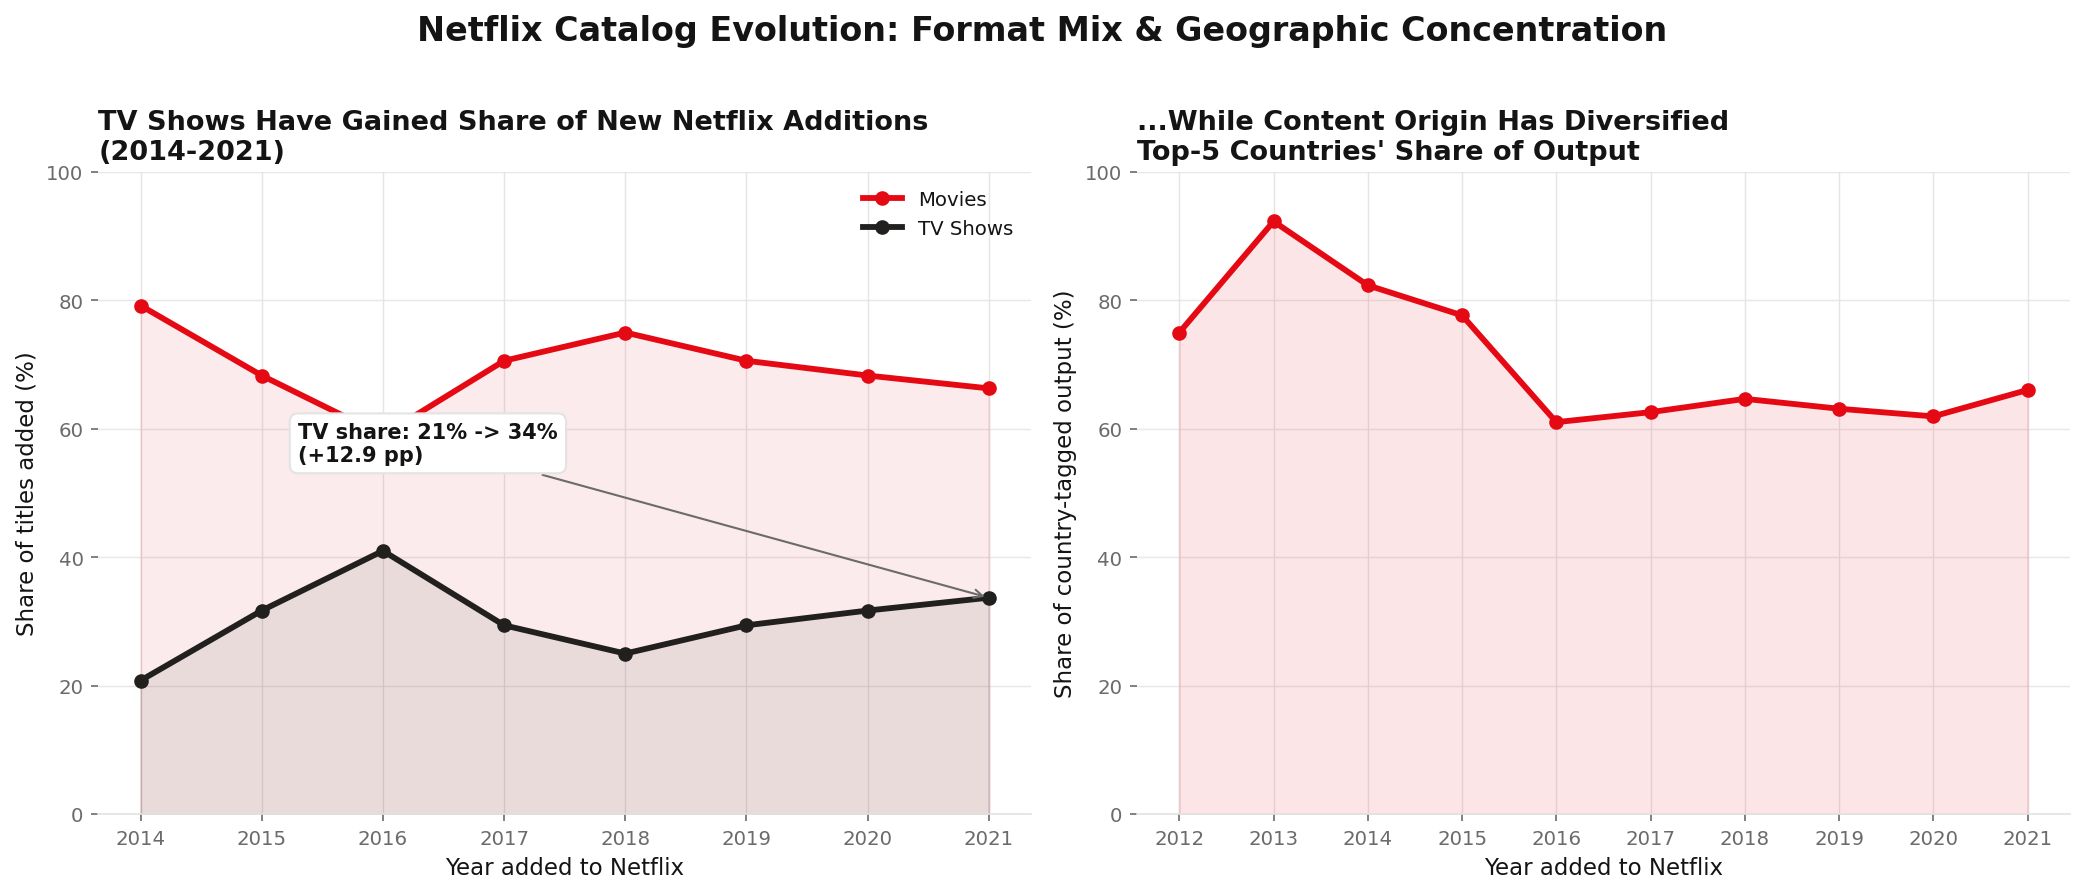

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
ax = axes[0]
ax.plot(main["year"], main["movie_pct"], color=MOVIE_COLOR, lw=2.8, marker="o", label="Movies")
ax.plot(main["year"], main["tv_pct"], color=TV_COLOR, lw=2.8, marker="o", label="TV Shows")
ax.fill_between(main["year"], main["movie_pct"], alpha=0.08, color=MOVIE_COLOR)
ax.fill_between(main["year"], main["tv_pct"], alpha=0.08, color=TV_COLOR)
ax.set_ylim(0, 100); ax.set_xticks(main["year"])
ax.set_ylabel("Share of titles added (%)"); ax.set_xlabel("Year added to Netflix")
ax.set_title(f"TV Shows Have Gained Share of New Netflix Additions\n({int(main['year'].min())}-{int(main['year'].max())})",
             fontsize=13, loc="left")
clean_ax(ax, keep_left=True); ax.legend(loc="upper right")
ax.annotate(f"TV share: {first_row['tv_pct']:.0f}% -> {last_row['tv_pct']:.0f}%\n({pp_change:+.1f} pp)",
            xy=(last_row["year"], last_row["tv_pct"]),
            xytext=(main["year"].iloc[0] + 1.3, 55), fontsize=10, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=SUBTEXT),
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=GRID))

ax2 = axes[1]
yrs = top5_share.index.astype(int)
ax2.plot(yrs, top5_share.values, color=MOVIE_COLOR, lw=2.8, marker="o")
ax2.fill_between(yrs, top5_share.values, alpha=0.10, color=MOVIE_COLOR)
ax2.set_ylim(0, 100); ax2.set_xticks(yrs)
ax2.set_xlabel("Year added to Netflix"); ax2.set_ylabel("Share of country-tagged output (%)")
ax2.set_title(f"...While Content Origin Has Diversified\nTop-5 Countries' Share of Output", fontsize=13, loc="left")
clean_ax(ax2, keep_left=True)
fig.suptitle("Netflix Catalog Evolution: Format Mix & Geographic Concentration", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/01_trend_and_diversification.png", dpi=200, bbox_inches="tight")
plt.show()


**Key insights:**
- TV Shows' share of new additions rose from **[tv_pct_start]% to [tv_pct_end]%** ([pp_change] percentage
  points) between [start_year] and [end_year], while Movies' share fell correspondingly.
- The crossover point — where TV Shows overtook Movies as the dominant format added per year — occurred
  around **[crossover_year]**.
- The top-5 countries' share of country-tagged output declined from **[top5_start]% to [top5_end]%**,
  indicating Netflix diversified production/licensing beyond its historical content hubs (largely the US).
- These two trends together suggest a deliberate strategic pivot: fewer US-centric movie licenses, more
  serialized, internationally-produced content — consistent with Netflix's global originals push.

### Top 18 Content-Producing Countries


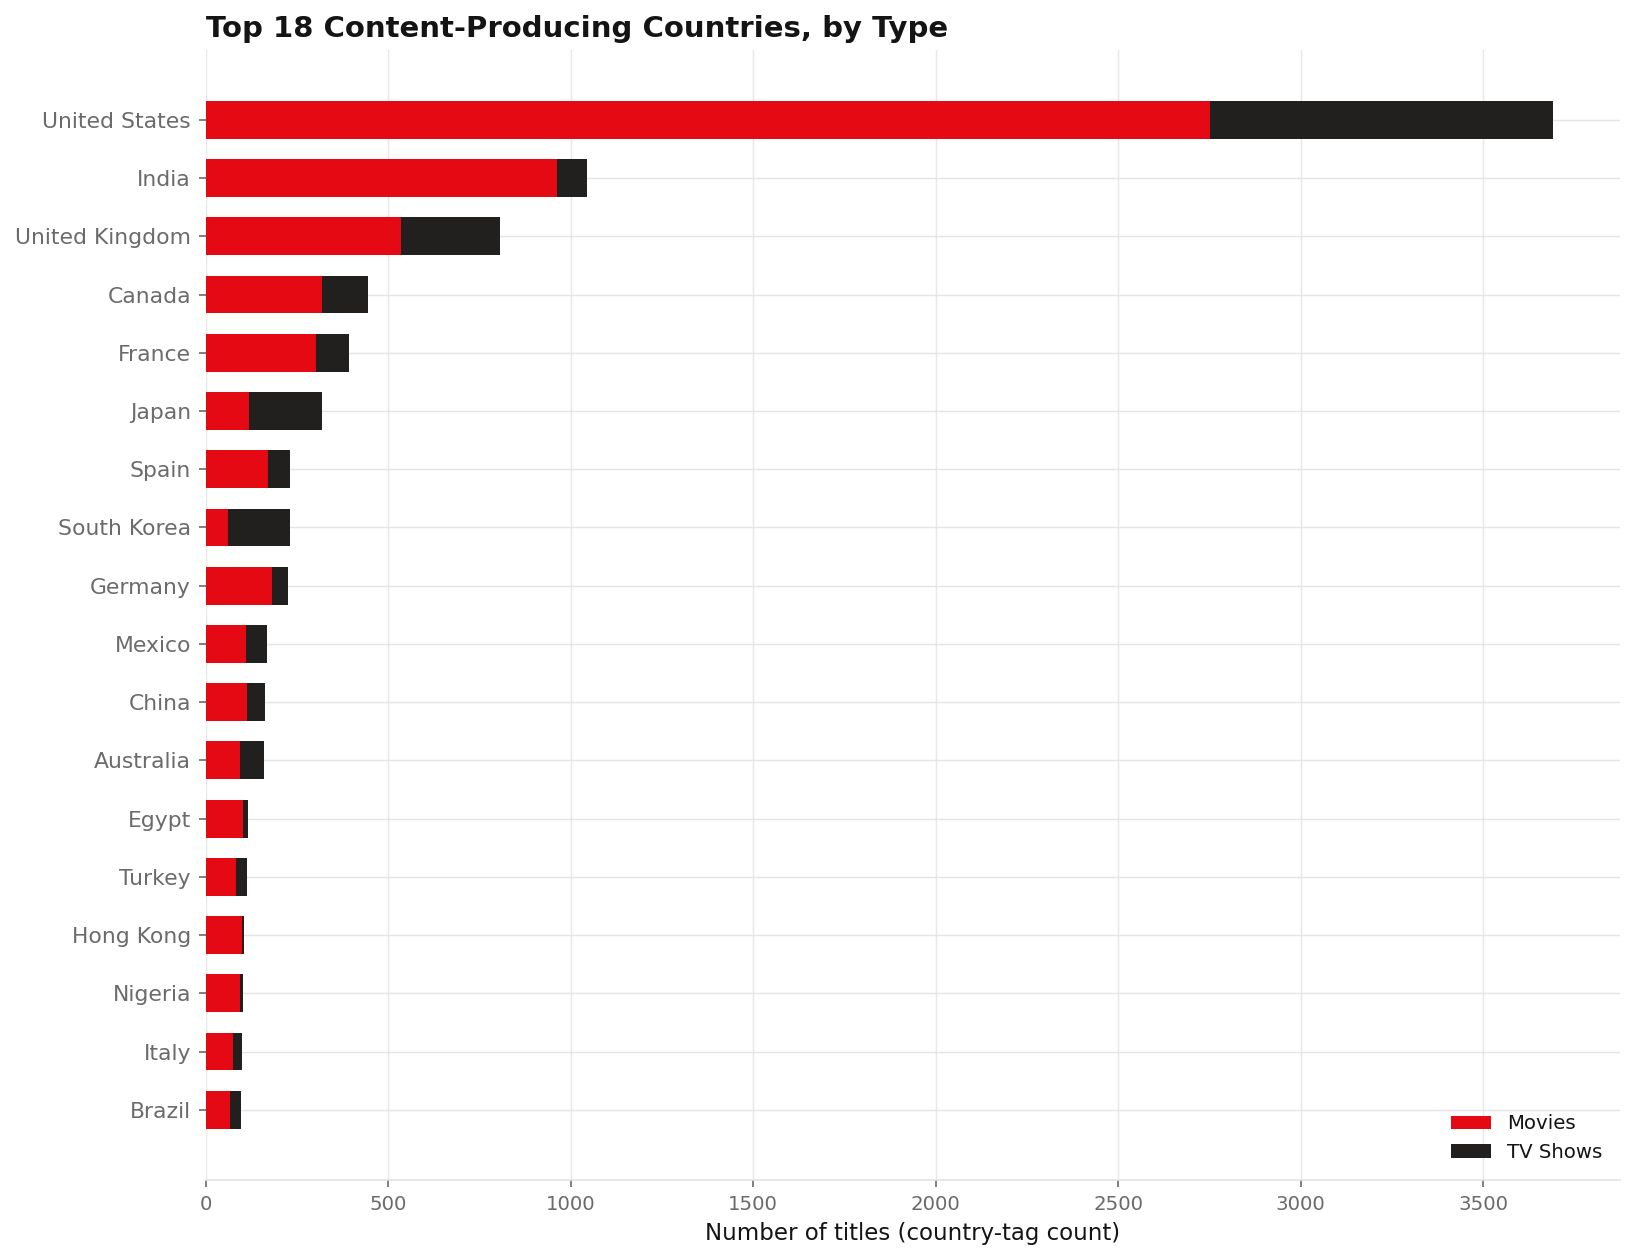

In [24]:
tc = top_countries.sort_values("total", ascending=True)
fig, ax = plt.subplots(figsize=(11, 8.5))
ax.barh(range(len(tc)), tc["Movie"], color=MOVIE_COLOR, label="Movies", height=0.65)
ax.barh(range(len(tc)), tc["TV Show"], left=tc["Movie"], color=TV_COLOR, label="TV Shows", height=0.65)
ax.set_yticks(range(len(tc))); ax.set_yticklabels(tc.index, fontsize=10.5)
ax.set_xlabel("Number of titles (country-tag count)")
ax.set_title("Top 18 Content-Producing Countries, by Type", fontsize=14, loc="left")
clean_ax(ax); ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/02_top_countries.png", dpi=200, bbox_inches="tight")
plt.show()

**Key insights:**
- **[top_country]** leads by a wide margin with **[n]** titles, followed by **[2nd_country]** and
  **[3rd_country]**.
- Movies dominate the mix for [country A, country B] while TV Shows make up a larger share for
  [country C, country D] — suggesting different regional content strategies (e.g., film-industry-heavy
  markets vs. serialized-drama markets like South Korea).
- Beyond the top 3-4 countries, output drops off sharply, reinforcing the long-tail concentration seen
  in Chart 1 even as diversification has increased over time.

### Top Genre Combinations: Movies vs. TV Shows


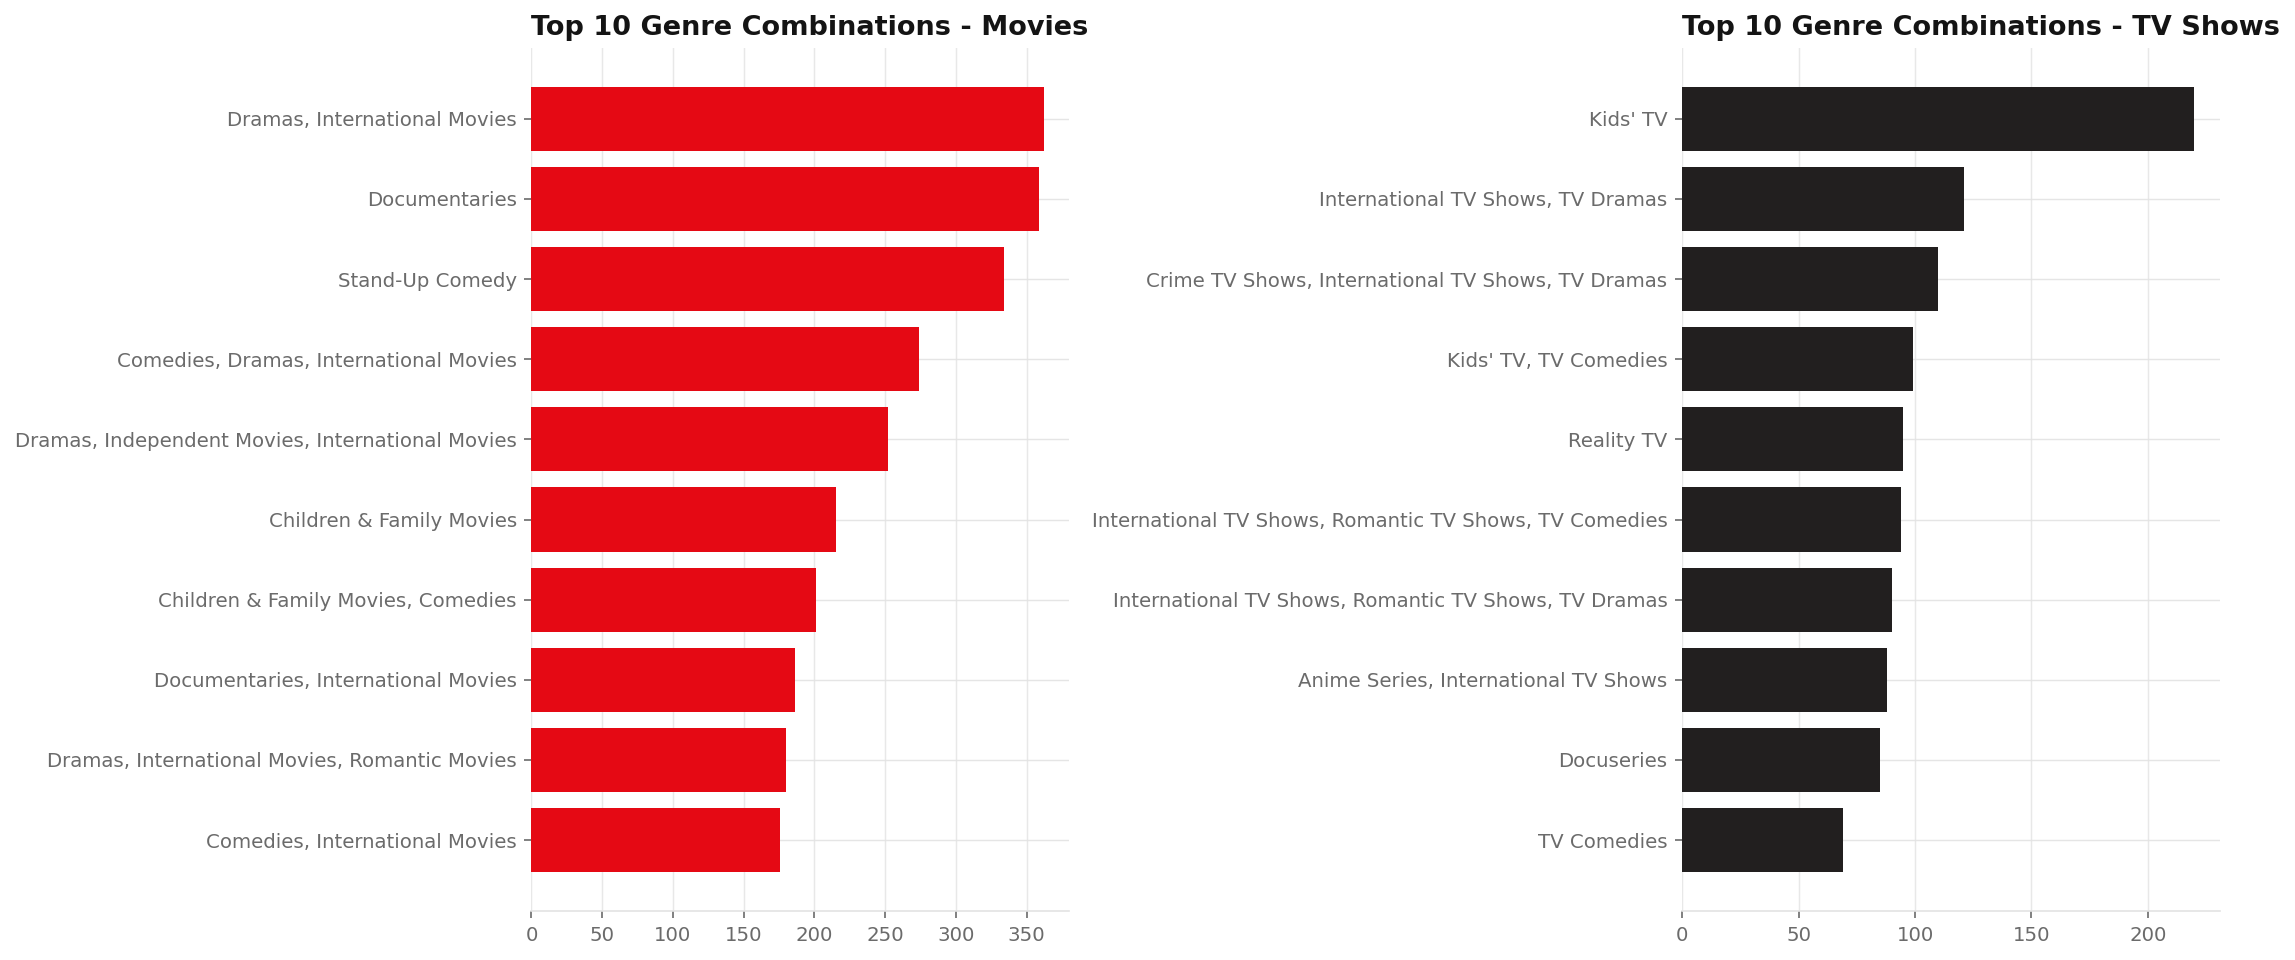

In [25]:
cm = combo_movie.sort_values(ascending=True); ct = combo_tv.sort_values(ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
axes[0].barh(range(len(cm)), cm.values, color=MOVIE_COLOR)
axes[0].set_yticks(range(len(cm))); axes[0].set_yticklabels(cm.index, fontsize=9.5)
axes[0].set_title("Top 10 Genre Combinations - Movies", fontsize=13, loc="left"); clean_ax(axes[0])
axes[1].barh(range(len(ct)), ct.values, color=TV_COLOR)
axes[1].set_yticks(range(len(ct))); axes[1].set_yticklabels(ct.index, fontsize=9.5)
axes[1].set_title("Top 10 Genre Combinations - TV Shows", fontsize=13, loc="left"); clean_ax(axes[1])
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/03_genre_combos.png", dpi=200, bbox_inches="tight")
plt.show()

**Key insights:**
- The most common movie genre pairing is **[combo_1]** ([n] titles), reflecting Netflix's reliance on
  broadly commercial, easily-marketable combinations (drama + comedy-type pairings tend to dominate).
- For TV Shows, **[combo_1_tv]** leads, pointing to a preference for [international/crime/drama]-flavored
  serialized content.
- Movies and TV shows show largely non-overlapping top combinations — the two formats seem to be
  programmed with distinct genre strategies rather than mirrored catalogs.

### Most Common Genre Tags


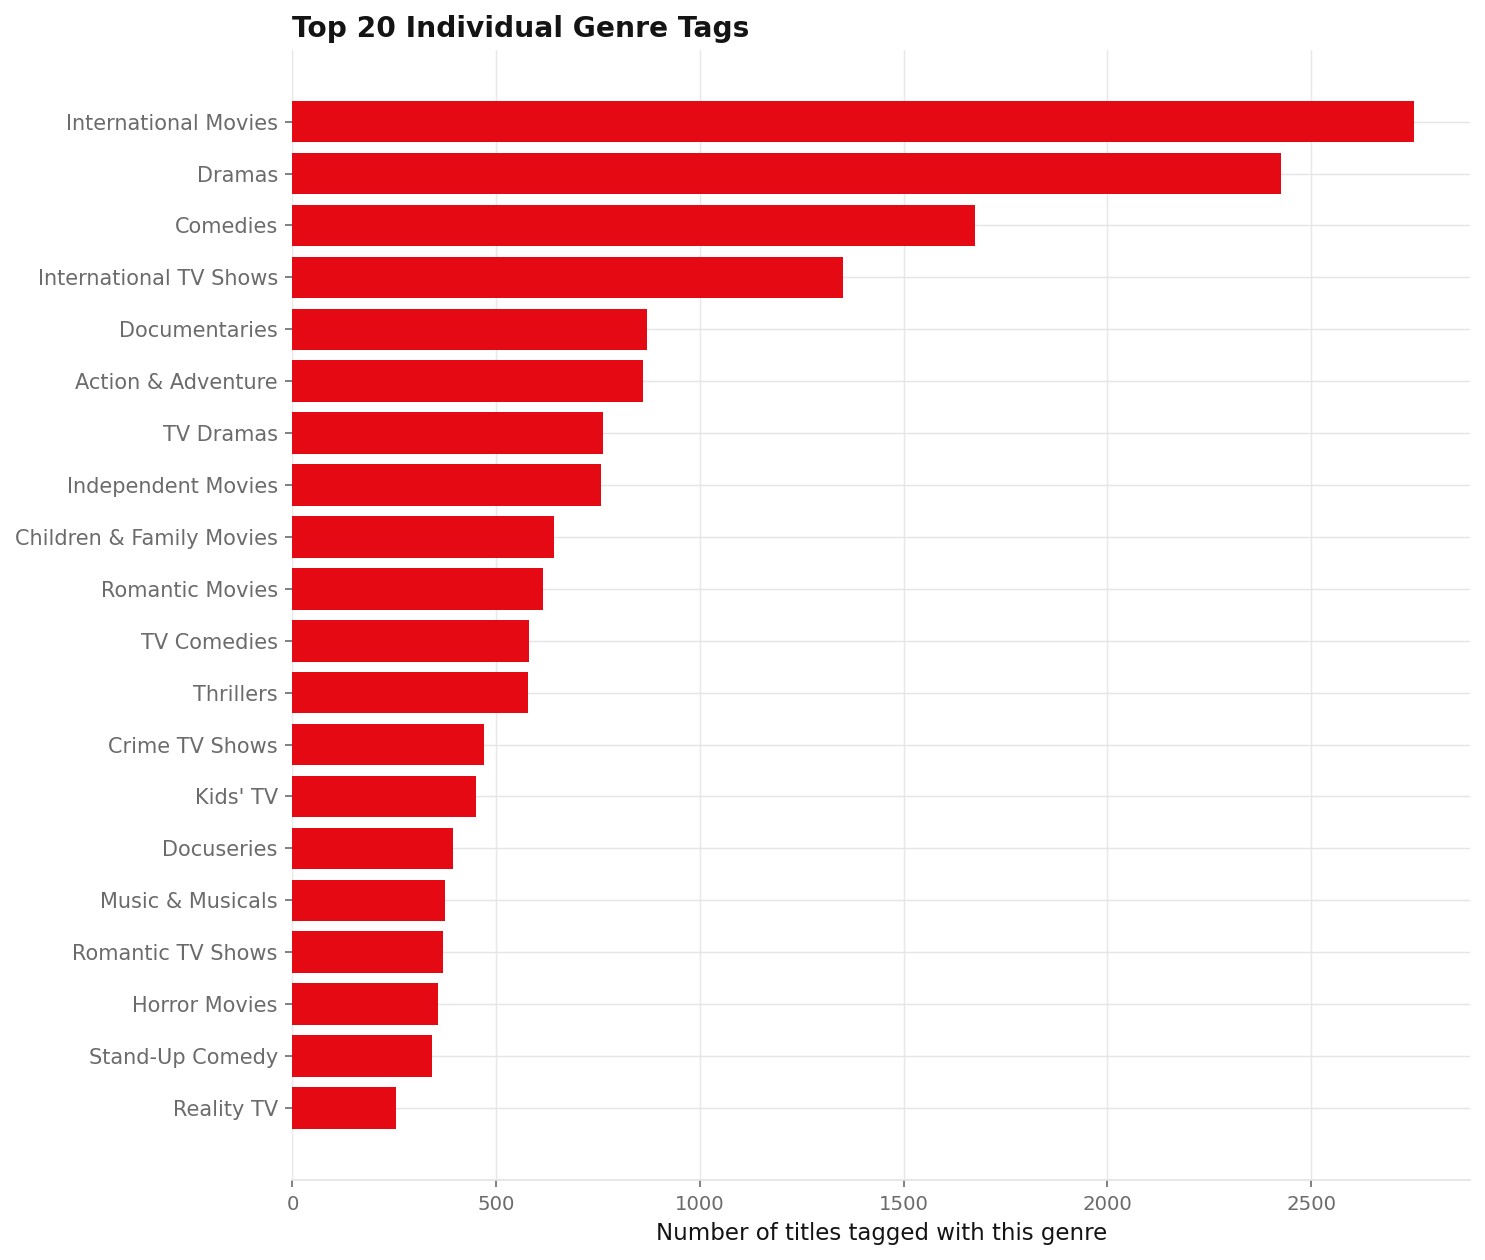

In [26]:
gc = genre_counts.sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 8.5))
ax.barh(range(len(gc)), gc.values, color=MOVIE_COLOR)
ax.set_yticks(range(len(gc))); ax.set_yticklabels(gc.index, fontsize=10)
ax.set_xlabel("Number of titles tagged with this genre")
ax.set_title("Top 20 Individual Genre Tags", fontsize=13.5, loc="left"); clean_ax(ax)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/04_individual_genres.png", dpi=200, bbox_inches="tight")
plt.show()

**Key insights:**
- **[top_genre]** is the single most-used tag, appearing on **[n]** titles, well ahead of
  **[2nd_genre]** and **[3rd_genre]**.
- International/regional tags (e.g., "International Movies," "International TV Shows") rank highly,
  consistent with the geographic diversification trend in Chart 1.
- The long tail of niche genres (documentaries, anime, classics) each account for a small slice —
  Netflix's catalog is genre-concentrated at the top but long-tailed overall.

### Genre Co-occurrence Patterns


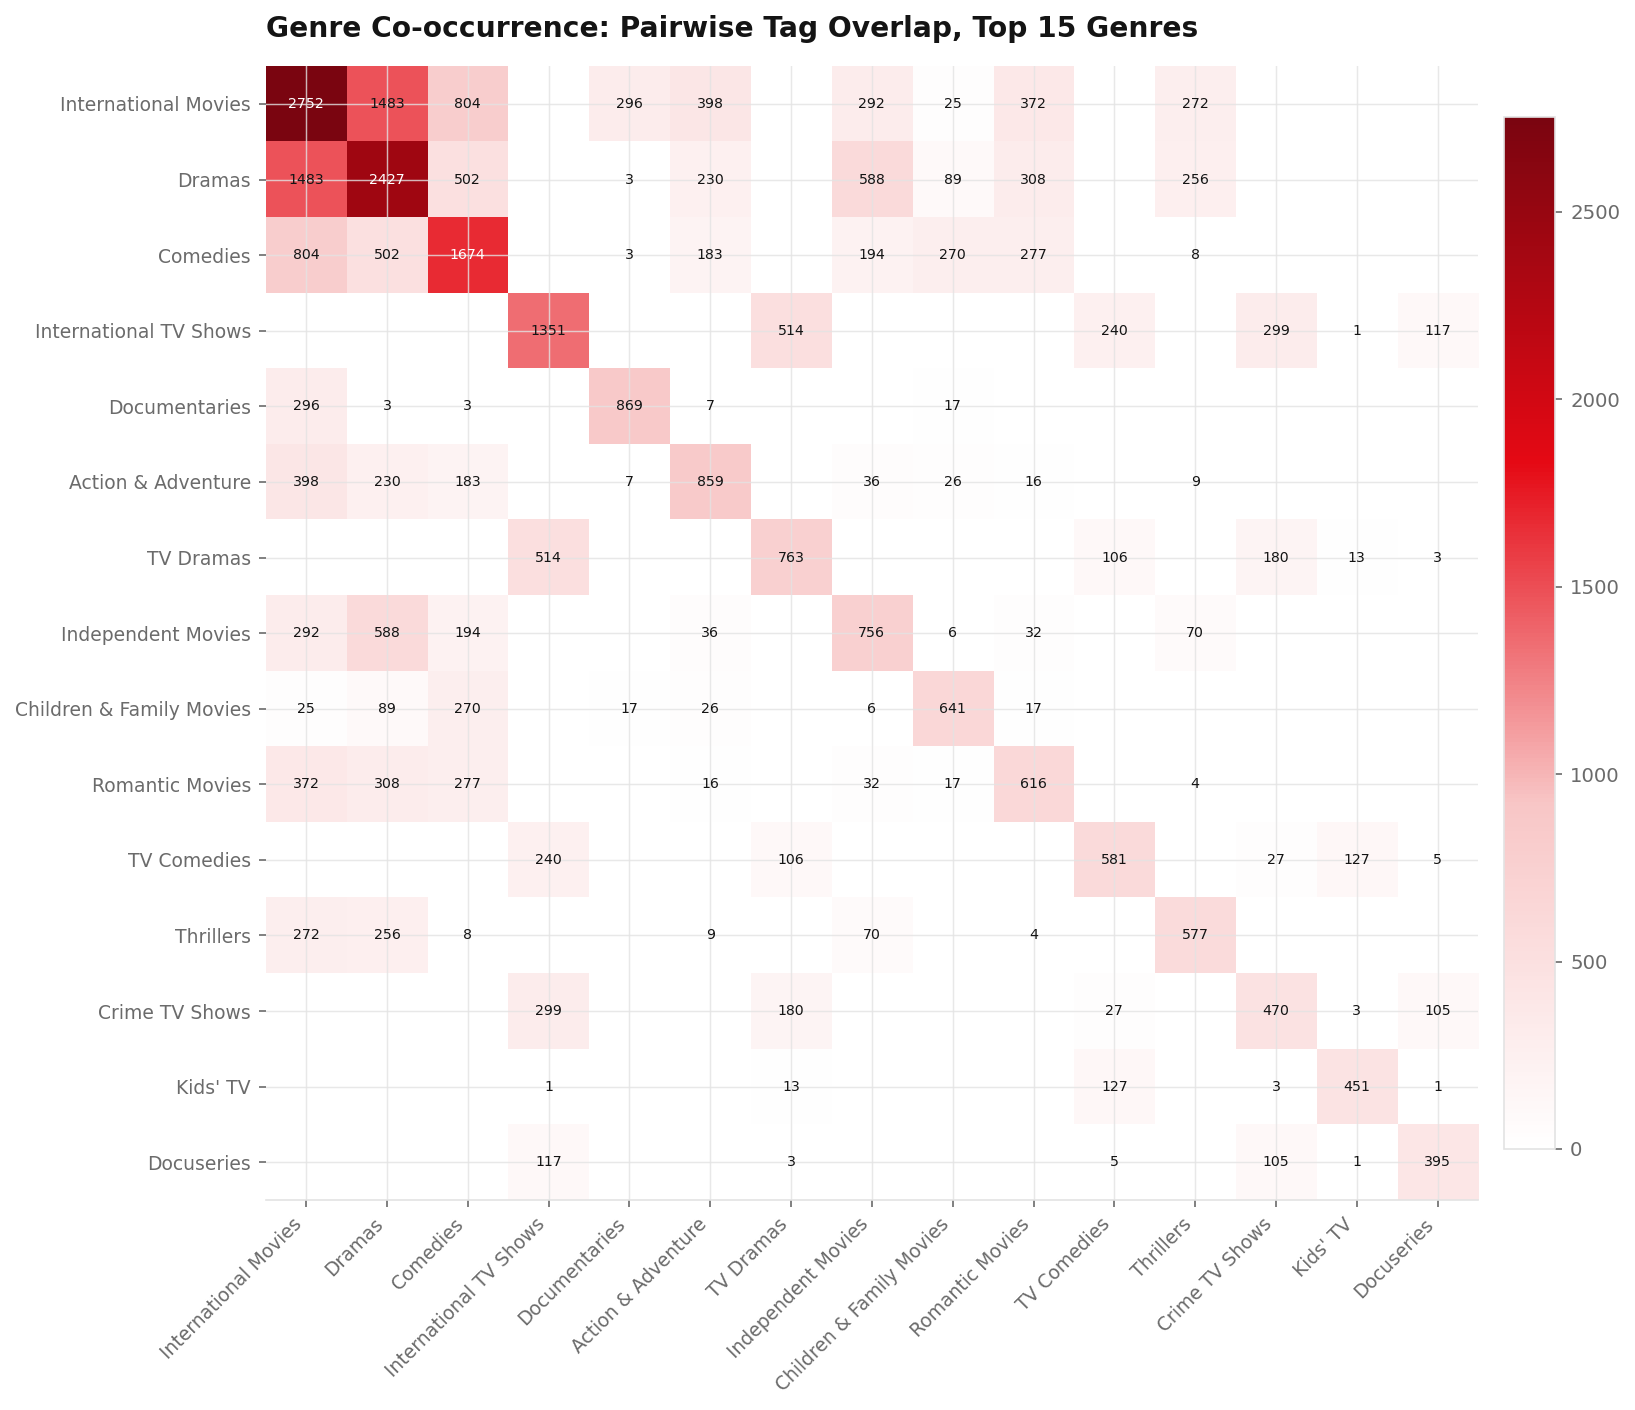

In [27]:
order = cooc.values.diagonal().argsort()[::-1]
labels = cooc.index[order]; mat = cooc.loc[labels, labels].values.astype(float)
cmap = LinearSegmentedColormap.from_list("netflix_seq", ["#FFFFFF", "#F8C6C6", "#E50914", "#7A0510"])
fig, ax = plt.subplots(figsize=(11, 9.5))
im = ax.imshow(mat, cmap=cmap, aspect="auto")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=9)
for i in range(len(labels)):
    for j in range(len(labels)):
        if mat[i, j] > 0:
            ax.text(j, i, f"{int(mat[i,j])}", ha="center", va="center", fontsize=6.8,
                     color="white" if mat[i, j] > mat.max() * 0.55 else TEXT)
ax.set_title("Genre Co-occurrence: Pairwise Tag Overlap, Top 15 Genres", fontsize=13.5, loc="left", pad=14)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/05_genre_cooccurrence_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()



**Key insights:**
- **[genre_A]** and **[genre_B]** show the strongest pairwise overlap ([n] shared titles), indicating
  these tags are frequently applied together (a common Netflix multi-tagging pattern).
- The diagonal (self-counts) confirms **[largest_genre]** as the highest-volume tag overall, matching
  Chart 4.
- Clusters of high co-occurrence around [genre cluster, e.g., Drama/Romance/Comedy] suggest Netflix
  tends to stack complementary genres on the same title to maximize discoverability, rather than
  using single, narrow classifications.